In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv('breast-cancer.csv')
df.drop(columns=['id'], inplace=True)
df['diagnosis_num'] = df['diagnosis'].map({'M': 1, 'B': 0})
df.reset_index(drop=True, inplace=True)

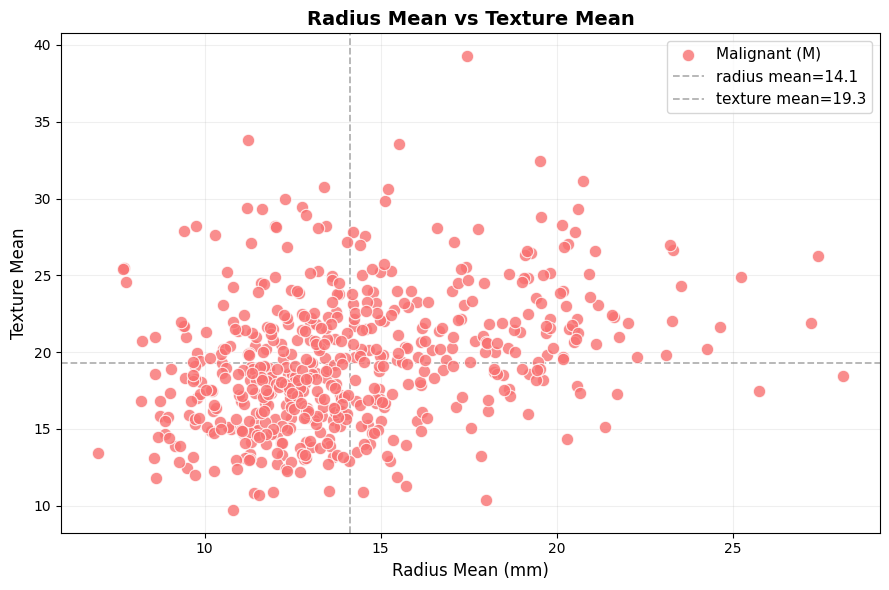

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['radius_mean'], df['texture_mean'],
           c='#f87171', s=80, alpha=0.8,
           edgecolors='white', linewidth=0.8,
           label='Malignant (M)', zorder=3)

# mean reference lines
mean_r = df['radius_mean'].mean()
mean_t = df['texture_mean'].mean()
ax.axvline(mean_r, color='gray', lw=1.3, ls='--', alpha=0.6, label=f'radius mean={mean_r:.1f}')
ax.axhline(mean_t, color='gray', lw=1.3, ls='--', alpha=0.6, label=f'texture mean={mean_t:.1f}')

ax.set_title('Radius Mean vs Texture Mean', fontsize=14, fontweight='bold')
ax.set_xlabel('Radius Mean (mm)', fontsize=12)
ax.set_ylabel('Texture Mean', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

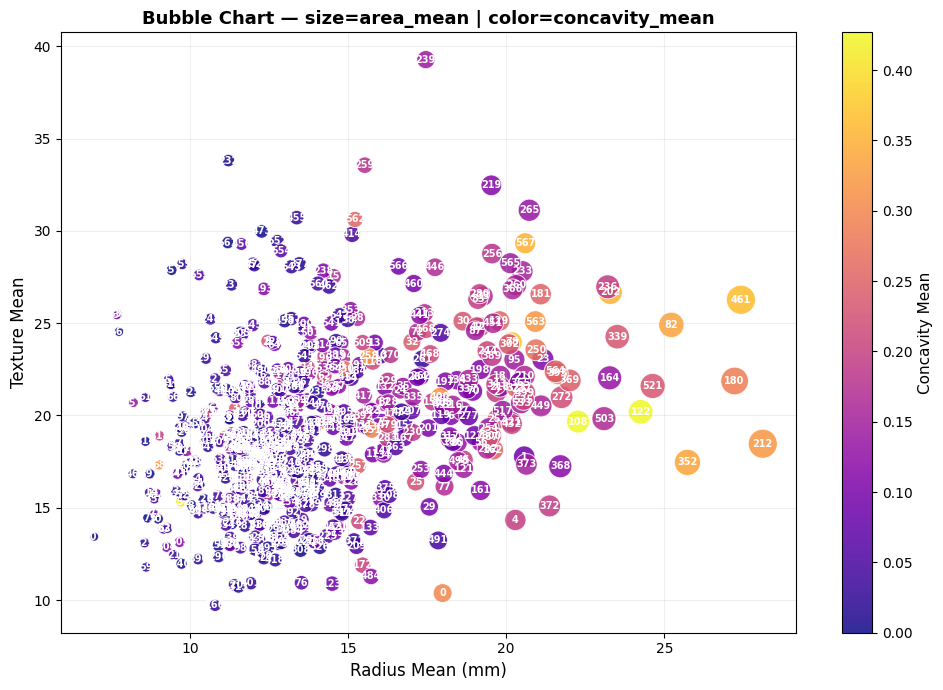

In [4]:
fig, ax = plt.subplots(figsize=(10, 7))

# bubble size = area_mean (normalize করে 40–440 range-এ আনো)
sizes = (df['area_mean'] - df['area_mean'].min()) / \
        (df['area_mean'].max() - df['area_mean'].min()) * 400 + 40

sc = ax.scatter(df['radius_mean'], df['texture_mean'],
                c=df['concavity_mean'],   # color = 3rd dimension
                cmap='plasma',
                s=sizes,                  # size  = 4th dimension
                alpha=0.85,
                edgecolors='white', linewidth=0.7)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Concavity Mean', fontsize=11)

# patient index label ভেতরে
for i, row in df.iterrows():
    ax.annotate(str(i), (row['radius_mean'], row['texture_mean']),
                fontsize=7, ha='center', va='center',
                color='white', fontweight='bold')

ax.set_title('Bubble Chart — size=area_mean | color=concavity_mean',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Radius Mean (mm)', fontsize=12)
ax.set_ylabel('Texture Mean', fontsize=12)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

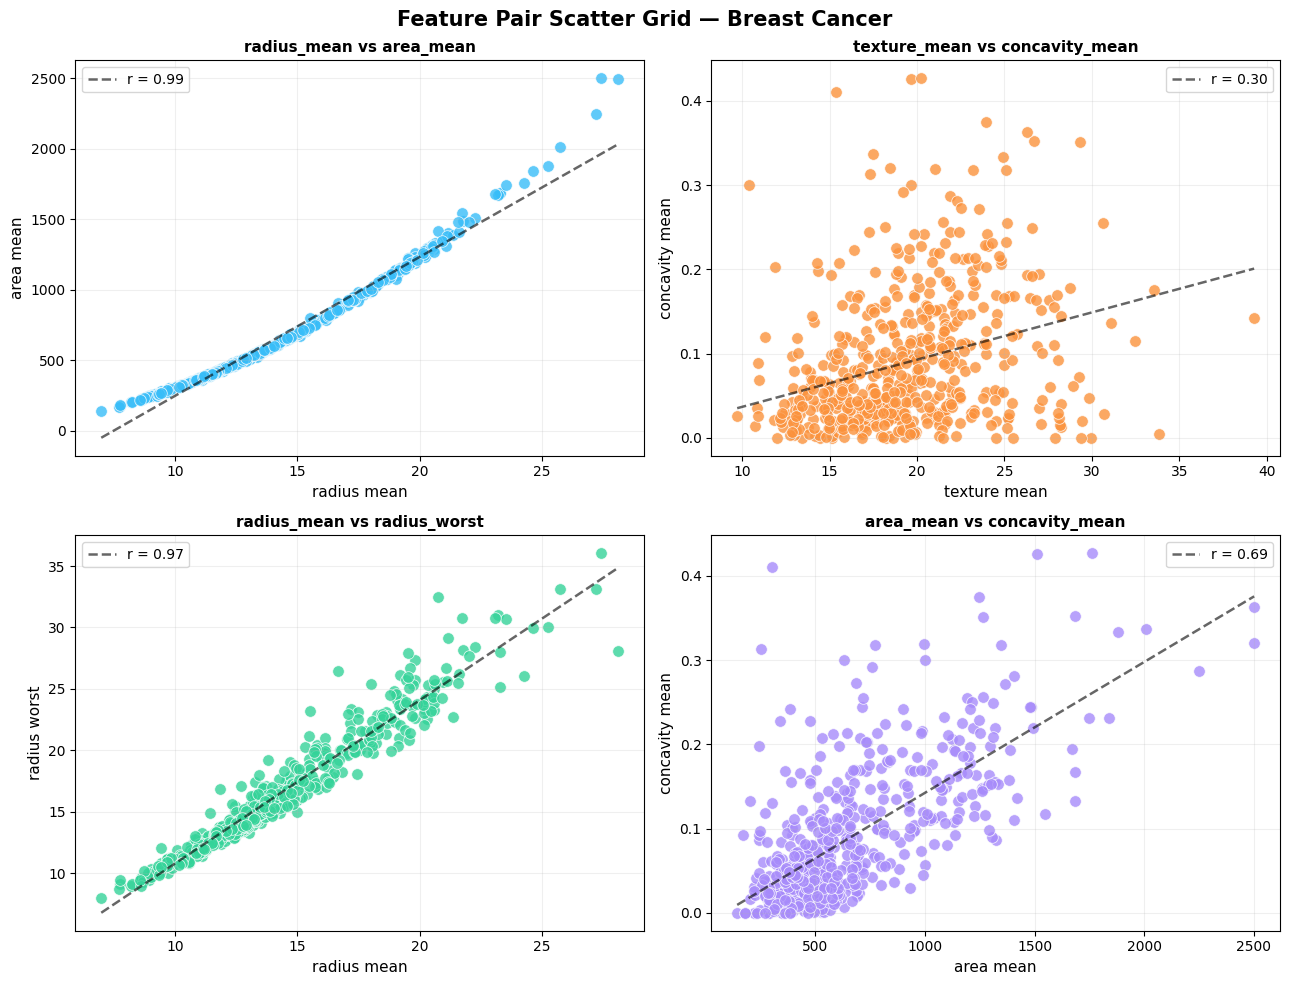

In [5]:
pairs = [
    ('radius_mean',  'area_mean',      '#38bdf8'),
    ('texture_mean', 'concavity_mean', '#fb923c'),
    ('radius_mean',  'radius_worst',   '#34d399'),
    ('area_mean',    'concavity_mean', '#a78bfa'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, (xcol, ycol, color) in zip(axes.flat, pairs):
    ax.scatter(df[xcol], df[ycol],
               c=color, s=70, alpha=0.8,
               edgecolors='white', linewidth=0.6)

    # correlation line: np.polyfit degree=1 → straight line
    m, b = np.polyfit(df[xcol], df[ycol], 1)
    x_line = np.linspace(df[xcol].min(), df[xcol].max(), 100)
    r = np.corrcoef(df[xcol], df[ycol])[0, 1]
    ax.plot(x_line, m * x_line + b,
            color='black', lw=1.8, ls='--', alpha=0.6, label=f'r = {r:.2f}')

    ax.set_xlabel(xcol.replace('_', ' '), fontsize=11)
    ax.set_ylabel(ycol.replace('_', ' '), fontsize=11)
    ax.set_title(f'{xcol} vs {ycol}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.2)

fig.suptitle('Feature Pair Scatter Grid — Breast Cancer',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()